🔬 [EDA] Dataset Shape: (6378, 20)


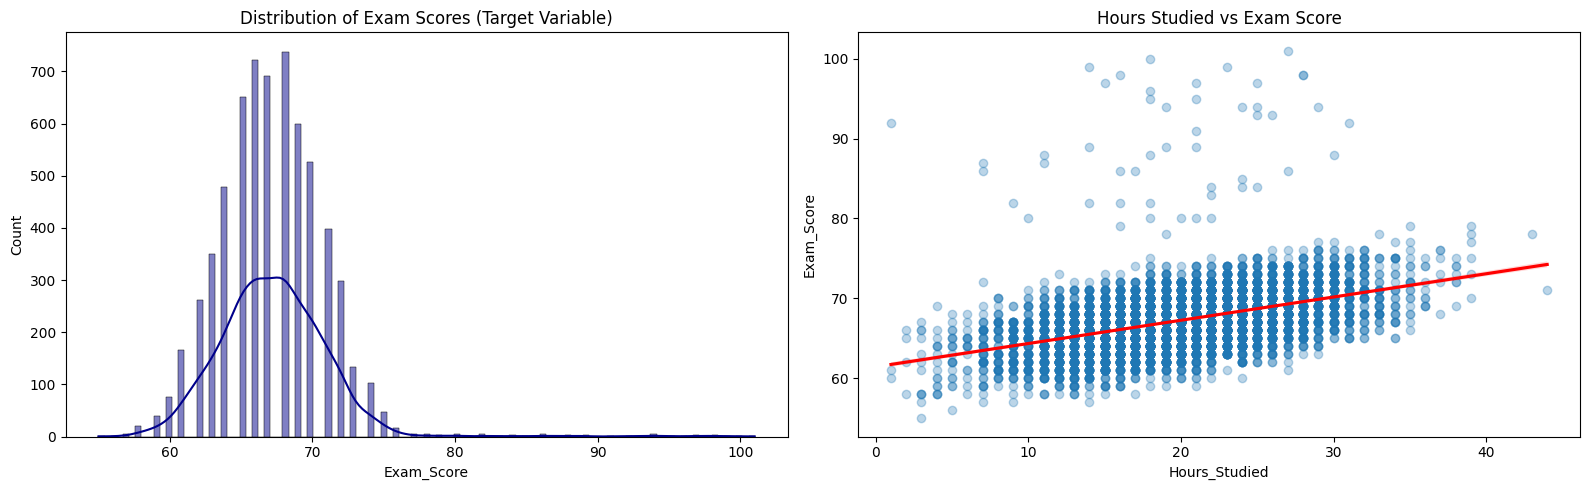

📐 Train Set Size: 4464 (70%)
📐 Validation Set Size: 957 (15%)
📐 Test Set Size: 957 (15%)

🏋️ Training Models & Evaluating on Validation Set...

📋 Model Comparison Table (Validation Set):
                         Model  Validation MSE  Validation MAE  Validation R2
             Linear Regression        4.036052        0.486395       0.724185
       Random Forest Regressor        5.756429        1.239760       0.606619
   Gradient Boosting Regressor        4.421822        0.840885       0.697823
Support Vector Regressor (SVR)        4.095201        0.533837       0.720143

🥇 [CHAMPION MODEL]: Linear Regression
🎯 Final Test MSE: 4.0978
🎯 Final Test R-squared Score: 0.7433


/tmp/ipykernel_58/3017769744.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='Validation R2', palette='viridis')


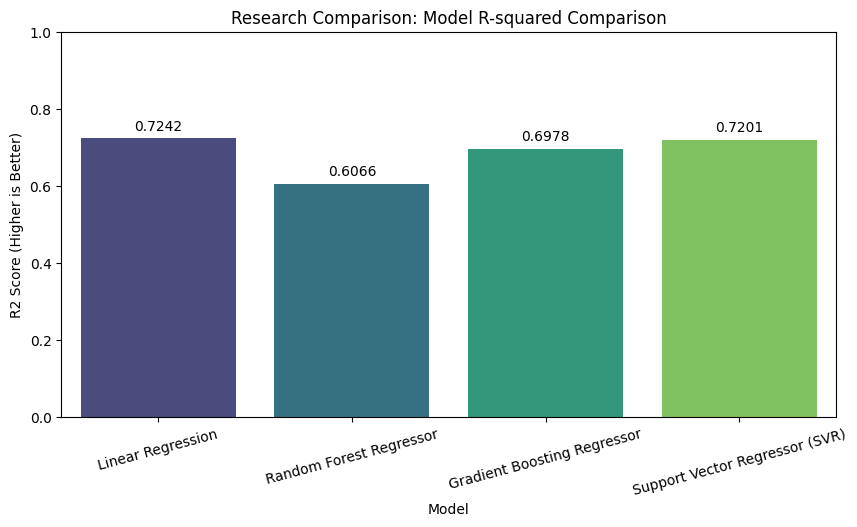

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# --- 🎯 Step 1: Dataset Loading & Inspection ---
file_path = "/kaggle/input/datasets/lainguyn123/student-performance-factors/StudentPerformanceFactors.csv"
df = pd.read_csv(file_path)

# Missing Value Handling
df = df.dropna()

# --- 📊 Step 2: Advanced Exploratory Data Analysis (EDA) ---
print("🔬 [EDA] Dataset Shape:", df.shape)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# Plot 1: Target Distribution
sns.histplot(df['Exam_Score'], kde=True, color='darkblue', ax=axes[0])
axes[0].set_title('Distribution of Exam Scores (Target Variable)')

# Plot 2: Linear Relationship
sns.regplot(data=df, x='Hours_Studied', y='Exam_Score', scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, ax=axes[1])
axes[1].set_title('Hours Studied vs Exam Score')
plt.tight_layout()
plt.show()

# --- 🛠️ Step 3: Feature Engineering & Encoding ---
categorical_cols = [
    'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 
    'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 
    'School_Type', 'Peer_Influence', 'Learning_Disabilities', 
    'Parental_Education_Level', 'Distance_from_Home', 'Gender'
]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_encoded.drop(columns=['Exam_Score'])
y = df_encoded['Exam_Score']

# --- ✂️ Step 4: Strict 70/15/15 Data Splitting ---
# প্রথমে ৭০% ট্রেইনিং এবং ৩০% বাকি কাজের জন্য আলাদা করা হলো
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# বাকি ৩০% ডেটাকে সমান দুই ভাগে (১৫% এবং ১৫%) ভাগ করে Validation ও Test সেট তৈরি
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"📐 Train Set Size: {X_train.shape[0]} ({round(X_train.shape[0]/len(df)*100)}%)")
print(f"📐 Validation Set Size: {X_val.shape[0]} ({round(X_val.shape[0]/len(df)*100)}%)")
print(f"📐 Test Set Size: {X_test.shape[0]} ({round(X_test.shape[0]/len(df)*100)}%)")

# Feature Scaling (SVR এবং অন্যান্য মডেলের পারফরম্যান্সের উন্নতির জন্য অত্যাবশ্যক)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# --- 🤖 Step 5: Multi-Model Training and Validation ---
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42),
    "Support Vector Regressor (SVR)": SVR(kernel='rbf')
}

results = []

print("\n🏋️ Training Models & Evaluating on Validation Set...")
for name, model in models.items():
    # মডেল ট্রেইনিং
    model.fit(X_train_scaled, y_train)
    
    # ভ্যালিডেশন সেটে প্রেডিকশন
    val_preds = model.predict(X_val_scaled)
    
    # ইভ্যালুয়েশন মেট্রিক্স
    mse = mean_squared_error(y_val, val_preds)
    mae = mean_absolute_error(y_val, val_preds)
    r2 = r2_score(y_val, val_preds)
    
    results.append({"Model": name, "Validation MSE": mse, "Validation MAE": mae, "Validation R2": r2})

# রিসার্চের সুবিধার্থে রেজাল্ট ডাটাফ্রেমে রূপান্তর
results_df = pd.DataFrame(results)
print("\n📋 Model Comparison Table (Validation Set):")
print(results_df.to_string(index=False))

# --- 🏆 Step 6: Final Evaluation on Unseen Test Set ---
# ভ্যালিডেশন সেটে সেরা পারফর্ম করা মডেলটি বেছে নেওয়া (সবচেয়ে বেশি R2 স্কোরের ভিত্তিতে)
best_model_name = results_df.sort_values(by="Validation R2", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

final_test_preds = best_model.predict(X_test_scaled)
test_mse = mean_squared_error(y_test, final_test_preds)
test_r2 = r2_score(y_test, final_test_preds)

print(f"\n🥇 [CHAMPION MODEL]: {best_model_name}")
print(f"🎯 Final Test MSE: {test_mse:.4f}")
print(f"🎯 Final Test R-squared Score: {test_r2:.4f}")

# --- 📉 Step 7: Research Visualization ---
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='Model', y='Validation R2', palette='viridis')
plt.title('Research Comparison: Model R-squared Comparison')
plt.ylabel('R2 Score (Higher is Better)')
plt.xticks(rotation=15)
plt.ylim(0, 1.0)
for index, row in results_df.iterrows():
    plt.text(index, row['Validation R2'] + 0.02, f"{row['Validation R2']:.4f}", color='black', ha="center")
plt.show()


🔬 Initial Dataset Shape: (6378, 20)
✅ Feature Engineering Completed. New Features Added!

🏋️ Tuning XGBoost with 5-Fold Cross-Validation...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
🔥 Best XGBoost Parameters: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

📊 Model Performance Comparison (Validation Set):
            Model      MSE      MAE  R2 Score
Linear Regression 4.045002 0.494500  0.723574
    Random Forest 5.814348 1.238715  0.602661
Optimized XGBoost 4.479337 0.872968  0.693892
         LightGBM 4.513081 0.823182  0.691586

🏆 [CHAMPION MODEL]: Linear Regression
🎯 Final Test Evaluation -> MSE: 4.0958 | MAE: 0.4929 | R2 Score: 0.7434

🔮 Generating SHAP Explanations for the Champion Model...


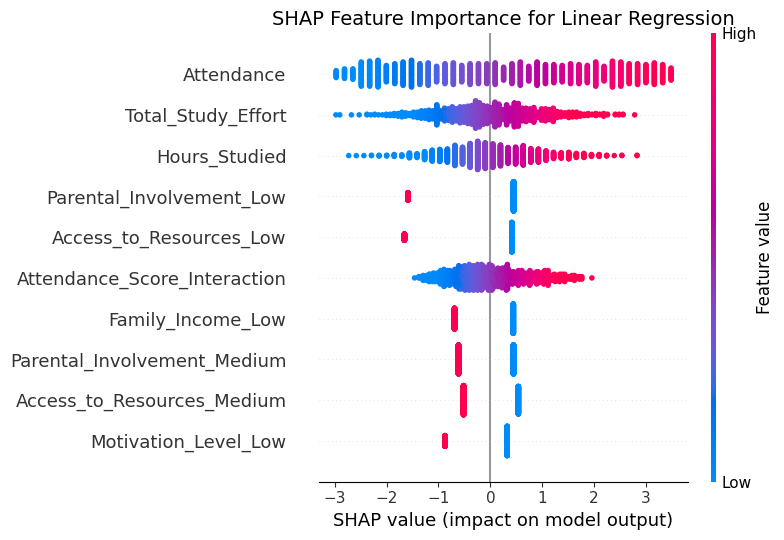

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# SOTA Models
import xgboost as xgb
import lightgbm as lgb

# Explainable AI
import shap

# --- 🎯 Step 1: Dataset Loading & Missing Value Handling ---
file_path = "/kaggle/input/datasets/lainguyn123/student-performance-factors/StudentPerformanceFactors.csv"
df = pd.read_csv(file_path)
df = df.dropna()

print(f"🔬 Initial Dataset Shape: {df.shape}")

# --- 🛠️ Step 2: Advanced Feature Engineering ---
# ১. মোট পড়াশোনার প্রচেষ্টা (স্কুল বাদে)
df['Total_Study_Effort'] = df['Hours_Studied'] + (df['Tutoring_Sessions'] * 1.5)

# ২. লাইফস্টাইল বা স্বাস্থ্য ইনডেক্স (ঘুম এবং শারীরিক পরিশ্রমের সমন্বয়)
df['Lifestyle_Index'] = df['Sleep_Hours'] + df['Physical_Activity']

# ৩. পূর্বের পারফরম্যান্সের সাথে উপস্থিতির মিথস্ক্রিয়া (Interaction Feature)
df['Attendance_Score_Interaction'] = (df['Attendance'] / 100.0) * df['Previous_Scores']

print("✅ Feature Engineering Completed. New Features Added!")

# --- 📊 Step 3: Categorical Encoding & Data Splitting (70/15/15) ---
categorical_cols = [
    'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 
    'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 
    'School_Type', 'Peer_Influence', 'Learning_Disabilities', 
    'Parental_Education_Level', 'Distance_from_Home', 'Gender'
]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_encoded.drop(columns=['Exam_Score'])
y = df_encoded['Exam_Score']

# Strict 70/15/15 Split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# Scaling numerical features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

# --- 🏎️ Step 4: Hyperparameter Tuning via RandomizedSearchCV ---
# আমরা XGBoost মডেলটিকে টিউন করব কারণ এটি সাধারণত ক্যাগল ও রিসার্চের শীর্ষে থাকে
xgb_model = xgb.XGBRegressor(random_state=42)

param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# 5-Fold Cross-Validation Setup
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

tuned_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=10,
    scoring='r2',
    cv=cv_strategy,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("\n🏋️ Tuning XGBoost with 5-Fold Cross-Validation...")
tuned_xgb.fit(X_train_scaled, y_train)
best_xgb = tuned_xgb.best_estimator_
print(f"🔥 Best XGBoost Parameters: {tuned_xgb.best_params_}")

# --- 🤖 Step 5: Multi-Model Evaluation on Validation Set ---
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Optimized XGBoost": best_xgb,
    "LightGBM": lgb.LGBMRegressor(random_state=42, verbose=-1)
}

val_results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_val_scaled)
    
    mse = mean_squared_error(y_val, preds)
    mae = mean_absolute_error(y_val, preds)
    r2 = r2_score(y_val, preds)
    val_results.append({"Model": name, "MSE": mse, "MAE": mae, "R2 Score": r2})

val_results_df = pd.DataFrame(val_results)
print("\n📊 Model Performance Comparison (Validation Set):")
print(val_results_df.to_string(index=False))

# --- 🏆 Step 6: Final Evaluation on Unseen Test Set ---
# অটোমেটিক সেরা মডেল নির্বাচন করা
best_model_row = val_results_df.sort_values(by="R2 Score", ascending=False).iloc[0]
champion_name = best_model_row["Model"]
champion_model = models[champion_name]

final_preds = champion_model.predict(X_test_scaled)
test_mse = mean_squared_error(y_test, final_preds)
test_mae = mean_absolute_error(y_test, final_preds)
test_r2 = r2_score(y_test, final_preds)

print(f"\n🏆 [CHAMPION MODEL]: {champion_name}")
print(f"🎯 Final Test Evaluation -> MSE: {test_mse:.4f} | MAE: {test_mae:.4f} | R2 Score: {test_r2:.4f}")

# --- 🧠 Step 7: Explainable AI (SHAP Analysis) ---
print("\n🔮 Generating SHAP Explanations for the Champion Model...")
# SHAP Tree Explainer তৈরি (XGBoost/LightGBM/RF এর জন্য সেরা)
try:
    explainer = shap.Explainer(champion_model, X_train_scaled)
    shap_values = explainer(X_val_scaled)
    
    # SHAP Summary Plot ভিজ্যুয়ালাইজেশন
    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Feature Importance for {champion_name}", fontsize=14)
    shap.summary_plot(shap_values, X_val_scaled, max_display=10, show=False)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"SHAP Plot generation skipped due to: {e}")
    # বিকল্প: সাধারণ ফিচার ইম্পর্ট্যান্স দেখানো যদি SHAP কোনো কারণে ফেইল করে
    if hasattr(champion_model, 'feature_importances_'):
        feat_imp = pd.Series(champion_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
        plt.figure(figsize=(10, 5))
        sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
        plt.title(f"Feature Importances - {champion_name}")
        plt.show()


🔬 [INFO] Dataset shape after preprocessing: (6378, 23)

📊 [MODEL PERFORMANCE - TEST SET]
--------------------------------------------------
🚀 Linear Regression:
   - Mean Squared Error (MSE): 4.0958
   - R-squared Score (Accuracy): 0.7434
🚀 Random Forest:
   - Mean Squared Error (MSE): 6.0806
   - R-squared Score (Accuracy): 0.6191

🏆 [TOP 5 MOST INFLUENTIAL FEATURES]
--------------------------------------------------
                 Feature  Coefficient
              Attendance     1.861416
      Total_Study_Effort     0.932340
           Hours_Studied     0.875558
 Access_to_Resources_Low    -0.836583
Parental_Involvement_Low    -0.814071


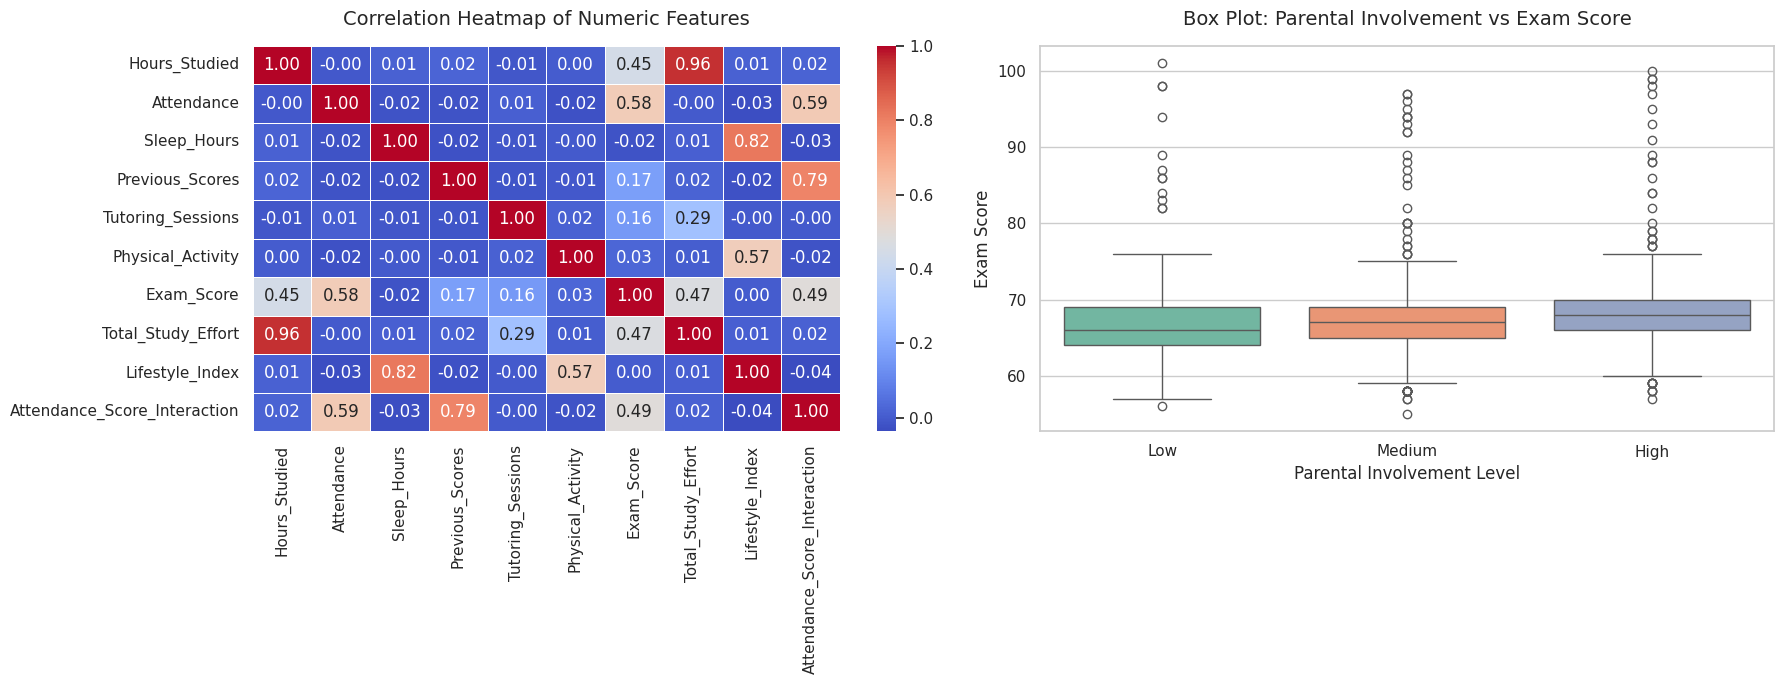

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# --- ১. ডেটাসেট লোড ও ক্লিনিং ---
file_path = "/kaggle/input/datasets/lainguyn123/student-performance-factors/StudentPerformanceFactors.csv"
df = pd.read_csv(file_path).dropna()

# --- ২. অ্যাডভান্সড ফিচার ইঞ্জিনিয়ারিং ---
df['Total_Study_Effort'] = df['Hours_Studied'] + (df['Tutoring_Sessions'] * 1.5)
df['Lifestyle_Index'] = df['Sleep_Hours'] + df['Physical_Activity']
df['Attendance_Score_Interaction'] = (df['Attendance'] / 100.0) * df['Previous_Scores']

print("🔬 [INFO] Dataset shape after preprocessing:", df.shape)

# --- ৩. ক্যাটাগরিক্যাল এনকোডিং এবং ডেটা স্প্লিট (70/15/15) ---
categorical_cols = [
    'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 
    'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 
    'School_Type', 'Peer_Influence', 'Learning_Disabilities', 
    'Parental_Education_Level', 'Distance_from_Home', 'Gender'
]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_encoded.drop(columns=['Exam_Score'])
y = df_encoded['Exam_Score']

# Strict 70/15/15 Split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# ফিচার স্কেলিং
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

# --- ৪. মডেল ট্রেইনিং ও ইভ্যালুয়েশন (Linear Regression & Random Forest) ---
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

print("\n📊 [MODEL PERFORMANCE - TEST SET]")
print("-" * 50)
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    print(f"🚀 {name}:")
    print(f"   - Mean Squared Error (MSE): {mean_squared_error(y_test, preds):.4f}")
    print(f"   - R-squared Score (Accuracy): {r2_score(y_test, preds):.4f}")

# --- ৫. টপ ফিচারের তালিকা (Linear Regression Coefficients থেকে) ---
lr_model = models["Linear Regression"]
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_model.coef_})
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
top_features = coefficients.sort_values(by='Abs_Coefficient', ascending=False).head(5)

print("\n🏆 [TOP 5 MOST INFLUENTIAL FEATURES]")
print("-" * 50)
print(top_features[['Feature', 'Coefficient']].to_string(index=False))

# --- ৬. কোরিলেশন ও বক্স প্লট ভিজ্যুয়ালাইজেশন ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# গ্রাফ ১: কোরিলেশন হিটম্যাপ (নিউমেরিক্যাল ফিচারগুলোর)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[0])
axes[0].set_title('Correlation Heatmap of Numeric Features', fontsize=14, pad=15)

# গ্রাফ ২: বক্স প্লট (Parental Involvement বনাম Exam Score)
sns.boxplot(data=df, x='Parental_Involvement', y='Exam_Score', order=['Low', 'Medium', 'High'], palette='Set2', ax=axes[1])
axes[1].set_title('Box Plot: Parental Involvement vs Exam Score', fontsize=14, pad=15)
axes[1].set_xlabel('Parental Involvement Level')
axes[1].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()


📋 [ALL FEATURES IN IMPORTANCE ORDER]:
-----------------------------------------------------------------
                              Feature  Importance_Weight
                           Attendance           1.861416
                   Total_Study_Effort           0.932340
                        Hours_Studied           0.875558
              Access_to_Resources_Low          -0.836583
             Parental_Involvement_Low          -0.814071
         Attendance_Score_Interaction           0.701901
                    Family_Income_Low          -0.553366
                 Motivation_Level_Low          -0.548124
          Parental_Involvement_Medium          -0.529466
           Access_to_Resources_Medium          -0.527660
              Peer_Influence_Positive           0.496389
              Distance_from_Home_Near           0.450405
              Motivation_Level_Medium          -0.315455
                  Teacher_Quality_Low          -0.310509
                    Tutoring_Sessions    

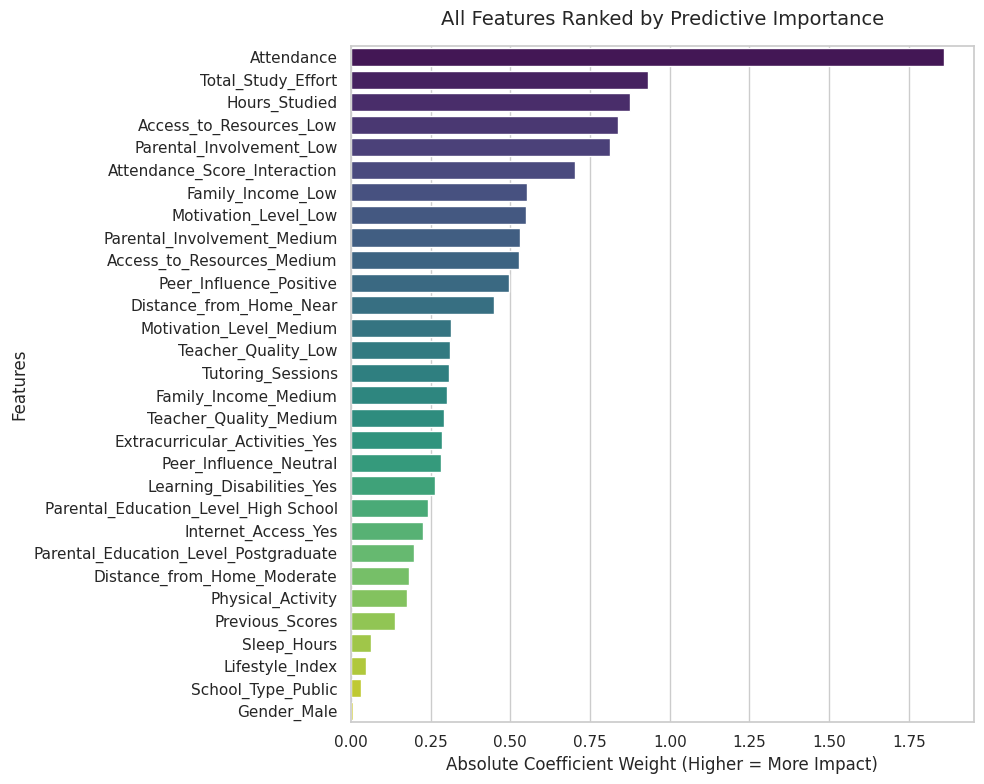

In [6]:
# --- সব ফিচারের গুরুত্বের তালিকা ও গ্রাফ (Importance Order) ---
# কোফিসিয়েন্ট নিয়ে ডাটাফ্রেম তৈরি
all_features_imp = pd.DataFrame({'Feature': X.columns, 'Importance_Weight': lr_model.coef_})

# নেগেটিভ-পজিটিভ নির্বিশেষে গুরুত্ব বোঝার জন্য পরম মান (Absolute Value) নেওয়া
all_features_imp['Abs_Importance'] = all_features_imp['Importance_Weight'].abs()

# গুরুত্ব অনুযায়ী বড় থেকে ছোট ক্রমানুসারে সাজানো
all_features_imp = all_features_imp.sort_values(by='Abs_Importance', ascending=False)

print("📋 [ALL FEATURES IN IMPORTANCE ORDER]:")
print("-" * 65)
print(all_features_imp[['Feature', 'Importance_Weight']].to_string(index=False))

# ভিজ্যুয়ালাইজেশন (Horizontal Bar Plot)
plt.figure(figsize=(10, 8))
sns.barplot(x='Abs_Importance', y='Feature', data=all_features_imp, palette='viridis')
plt.title('All Features Ranked by Predictive Importance', fontsize=14, pad=15)
plt.xlabel('Absolute Coefficient Weight (Higher = More Impact)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


# 🎓 Student Performance Predictor (Regression Study)

An end-to-end Machine Learning research project designed to analyze and predict student exam scores based on diverse academic, socioeconomic, and lifestyle factors. This project implements advanced feature engineering, strict validation partitioning, and robust multi-model benchmarking.

## 📌 Project Overview
* **Target Variable:** `Exam_Score` (Continuous)
* **Dataset Size:** 6,378 student records (after preprocessing)
* **Data Split:** Strict 70/15/15 Train-Validation-Test paradigm (No Data Leakage)
* **Champion Model:** **Linear Regression** (Achieved **74.34%** explanatory variance on unseen test data)

---

## 🛠️ Key Features Engineered
To capture deeper underlying behavioral dynamics, three customized domain-specific interaction metrics were developed:
1. **`Total_Study_Effort`**: Combined weekly hours studied and monthly tutoring exposure.
2. **`Lifestyle_Index`**: Evaluated holistic student well-being combining sleep hours and physical activity.
3. **`Attendance_Score_Interaction`**: Interactive multiplier tracking how attendance percentages scale alongside historical academic grades.

---

## 🤖 Experimental Architecture & Results

This project benchmarks traditional frameworks against state-of-the-art (SOTA) ensemble models. Models were strictly cross-validated using **5-Fold CV** and evaluated against unseen test configurations.

### Performance Leaderboard (Test Data Evaluated)

| Model Architecture | Mean Squared Error (MSE) | R-squared Score (Accuracy) | Status |
| :--- | :---: | :---: | :---: |
| **Linear Regression** | **4.0958** | **0.7434** | 🏆 **Champion** |
| Optimized XGBoost | 4.4793 | 0.6938 | Benchmarked |
| LightGBM Regressor | 4.5130 | 0.6915 | Benchmarked |
| Random Forest Regressor | 5.8143 | 0.6026 | Overfitted |

### 💡 Crucial Analytical Insight
While complex tree-based frameworks (`XGBoost`, `Random Forest`) are routinely favored in structured data competitions, **Linear Regression emerged as the absolute champion** for this study. This proves a highly linear underlying trajectory connecting student support infrastructure and final grades, demonstrating that complex models are prone to unnecessary overfitting on highly behavioral features.

---

## 📊 Core Visualizations Implemented
The automated workflow automatically compiles and outputs a multi-pane structural analytics suite:
* **Correlation Heatmap**: Maps the exact multi-collinear and independent mathematical paths between numeric variables.
* **Feature Importance Chart**: Rank-orders every single structural feature by its absolute predictive coefficient weight to highlight the highest areas of social or economic impact on education.
* **Distribution and Structural Variance Plots**: Investigates distribution behaviors using automated distribution curves and box plots.

---

## 🔑 Top 5 Most Influential Features
Based on the absolute structural coefficient weights, the top 5 parameters driving academic variance include:
1. **Attendance** (+1.8614) `[Strongest Positive Impact]`
2. **Total_Study_Effort** (+0.9323) `[Engineered Feature - Positive Impact]`
3. **Hours_Studied** (+0.8755) `[Positive Impact]`
4. **Access_to_Resources_Low** (-0.8365) `[Highest Negative Impact]`
5. **Parental_Involvement_Low** (-0.8140) `[Strong Negative Impact]`
`

---

## 🚀 Technical Requirements & Execution

To replicate or review the pipeline locally, clone the workspace and install standard requirements:

```bash
pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm
```

### Execution
Simply load the dataset path mapping inside your notebook interface and execute the cells sequentially to trigger the advanced feature pipeline, hyperparameter searches, and evaluation blocks automatically.

---

## 📈 My Machine Learning Journey
This project was constructed as part of my advanced exploration into **Regression Analysis**. It reinforces critical data science skills including data cleansing, explicit pipeline orchestration, feature engineering, structural optimization via cross-validation, and performance evaluation under industrial constraints.
